In [1]:
import pandas as pd
import glob

In [2]:
df = pd.read_csv('IRIS.xls')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df = df.drop_duplicates()

In [4]:
df.shape

(147, 5)

In [5]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  147 non-null    float64
 3   petal_width   147 non-null    float64
 4   species       147 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.9+ KB


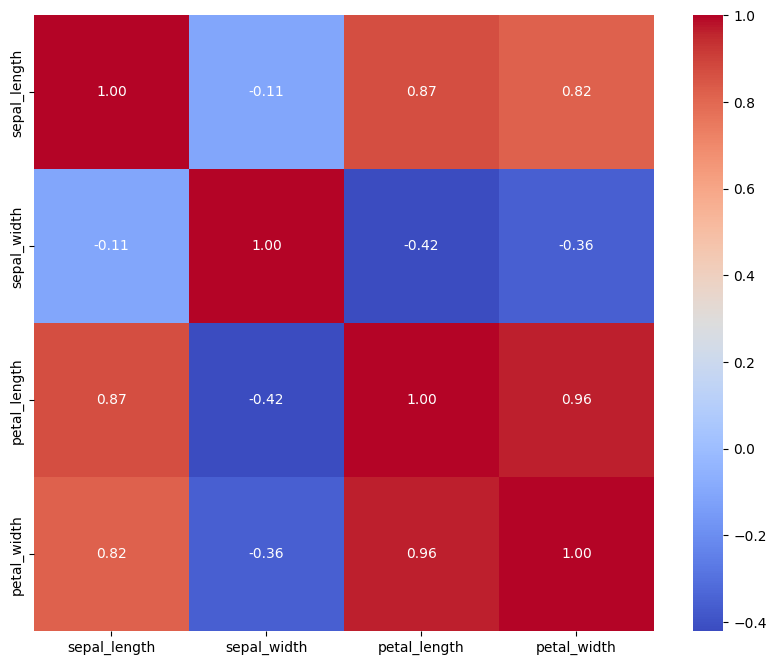

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [8]:
X = df.drop('species', axis=1)
y = df['species']

In [9]:
y.value_counts()

species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

In [10]:
from sklearn.model_selection import  train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train_scale = ss.fit_transform(X_train)
X_test_scale = ss.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

lr = LogisticRegression()
lr.fit(X_train_scale, y_train)

y_pred = lr.predict(X_test_scale)
y_pred_train = lr.predict(X_train_scale)

print('Train accuracy', accuracy_score(y_train, y_pred_train))
print('train precision', precision_score(y_train, y_pred_train, average='weighted'))
print('train recall', recall_score(y_train, y_pred_train, average='weighted'))
print('train f1', f1_score(y_train, y_pred_train, average='weighted'))

print('-'*20)
print('test accuracy', accuracy_score(y_test, y_pred))
print('test precision', precision_score(y_test, y_pred, average='weighted'))
print('test recall', recall_score(y_test, y_pred, average='weighted'))
print('test f1', f1_score(y_test, y_pred, average='weighted'))
print('classfication report', classification_report(y_test, y_pred))

Train accuracy 0.9743589743589743
train precision 0.974556747539862
train recall 0.9743589743589743
train f1 0.9743549673226186
--------------------
test accuracy 0.9333333333333333
test precision 0.9333333333333333
test recall 0.9333333333333333
test f1 0.9333333333333333
classfication report                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.89      0.89      0.89         9

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scale, y_train)

y_pred = knn.predict(X_test_scale)
y_pred_train = knn.predict(X_train_scale)

print('Train accuracy', accuracy_score(y_train, y_pred_train))
print('train precision', precision_score(y_train, y_pred_train, average='weighted'))
print('train recall', recall_score(y_train, y_pred_train, average='weighted'))
print('train f1', f1_score(y_train, y_pred_train, average='weighted'))

print('-'*20)
print('test accuracy', accuracy_score(y_test, y_pred))
print('test precision', precision_score(y_test, y_pred, average='weighted'))
print('test recall', recall_score(y_test, y_pred, average='weighted'))
print('test f1', f1_score(y_test, y_pred, average='weighted'))
print('classfication report', classification_report(y_test, y_pred))

Train accuracy 0.9658119658119658
train precision 0.9665831244778613
train recall 0.9658119658119658
train f1 0.9657905849275454
--------------------
test accuracy 0.9333333333333333
test precision 0.9333333333333333
test recall 0.9333333333333333
test f1 0.9333333333333333
classfication report                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.89      0.89      0.89         9

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



In [17]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_scale, y_train)

y_pred = svm.predict(X_test_scale)
y_pred_train = svm.predict(X_train_scale)

print('Train accuracy', accuracy_score(y_train, y_pred_train))
print('train precision', precision_score(y_train, y_pred_train, average='weighted'))
print('train recall', recall_score(y_train, y_pred_train, average='weighted'))
print('train f1', f1_score(y_train, y_pred_train, average='weighted'))

print('-'*20)
print('test accuracy', accuracy_score(y_test, y_pred))
print('test precision', precision_score(y_test, y_pred, average='weighted'))
print('test recall', recall_score(y_test, y_pred, average='weighted'))
print('test f1', f1_score(y_test, y_pred, average='weighted'))
print('classfication report', classification_report(y_test, y_pred))

Train accuracy 0.9829059829059829
train precision 0.9829059829059829
train recall 0.9829059829059829
train f1 0.9829059829059829
--------------------
test accuracy 0.9333333333333333
test precision 0.9333333333333333
test recall 0.9333333333333333
test f1 0.9333333333333333
classfication report                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.89      0.89      0.89         9

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



In [21]:
from sklearn.naive_bayes import GaussianNB

naive = GaussianNB()
naive.fit(X_train_scale, y_train)

y_pred = naive.predict(X_test_scale)
y_pred_train = naive.predict(X_train_scale)

print('Train accuracy', accuracy_score(y_train, y_pred_train))
print('train precision', precision_score(y_train, y_pred_train, average='weighted'))
print('train recall', recall_score(y_train, y_pred_train, average='weighted'))
print('train f1', f1_score(y_train, y_pred_train, average='weighted'))

print('-'*20)
print('test accuracy', accuracy_score(y_test, y_pred))
print('test precision', precision_score(y_test, y_pred, average='weighted'))
print('test recall', recall_score(y_test, y_pred, average='weighted'))
print('test f1', f1_score(y_test, y_pred, average='weighted'))

report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)
reports = pd.DataFrame(report)
reports

Train accuracy 0.9658119658119658
train precision 0.9658119658119658
train recall 0.9658119658119658
train f1 0.9658119658119658
--------------------
test accuracy 0.9666666666666667
test precision 0.9696969696969696
test recall 0.9666666666666667
test f1 0.9664799253034547


,Iris-setosa,Iris-versicolor,Iris-virginica,accuracy,macro avg,weighted avg
precision,1.0,0.909091,1.000000,0.966667,0.969697,0.969697
recall,1.0,1.000000,0.888889,0.966667,0.962963,0.966667
f1-score,1.0,0.952381,0.941176,0.966667,0.964519,0.966480
support,11.0,10.000000,9.000000,0.966667,30.000000,30.000000


In [21]:
from xgboost import XGBRFClassifier

naive = GaussianNB()
naive.fit(X_train_scale, y_train)

y_pred = naive.predict(X_test_scale)
y_pred_train = naive.predict(X_train_scale)

print('Train accuracy', accuracy_score(y_train, y_pred_train))
print('train precision', precision_score(y_train, y_pred_train, average='weighted'))
print('train recall', recall_score(y_train, y_pred_train, average='weighted'))
print('train f1', f1_score(y_train, y_pred_train, average='weighted'))

print('-'*20)
print('test accuracy', accuracy_score(y_test, y_pred))
print('test precision', precision_score(y_test, y_pred, average='weighted'))
print('test recall', recall_score(y_test, y_pred, average='weighted'))
print('test f1', f1_score(y_test, y_pred, average='weighted'))

report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)
reports = pd.DataFrame(report)
reports

Train accuracy 0.9658119658119658
train precision 0.9658119658119658
train recall 0.9658119658119658
train f1 0.9658119658119658
--------------------
test accuracy 0.9666666666666667
test precision 0.9696969696969696
test recall 0.9666666666666667
test f1 0.9664799253034547


,Iris-setosa,Iris-versicolor,Iris-virginica,accuracy,macro avg,weighted avg
precision,1.0,0.909091,1.000000,0.966667,0.969697,0.969697
recall,1.0,1.000000,0.888889,0.966667,0.962963,0.966667
f1-score,1.0,0.952381,0.941176,0.966667,0.964519,0.966480
support,11.0,10.000000,9.000000,0.966667,30.000000,30.000000
